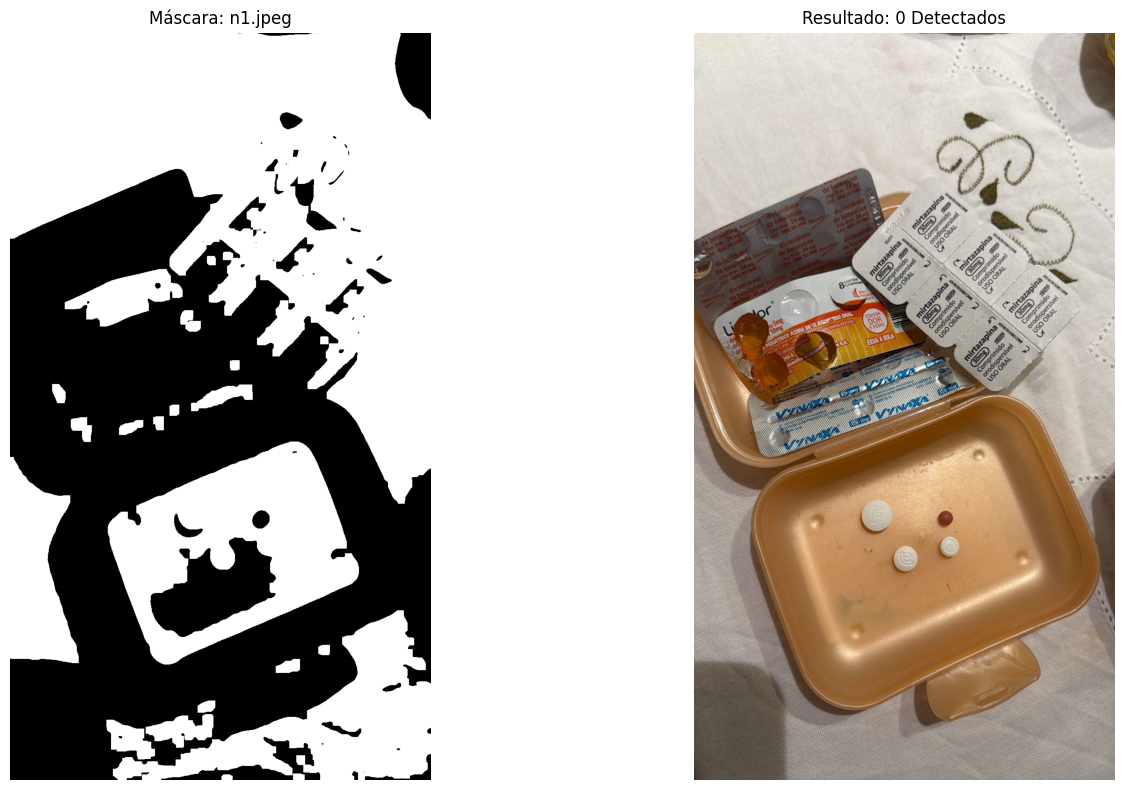

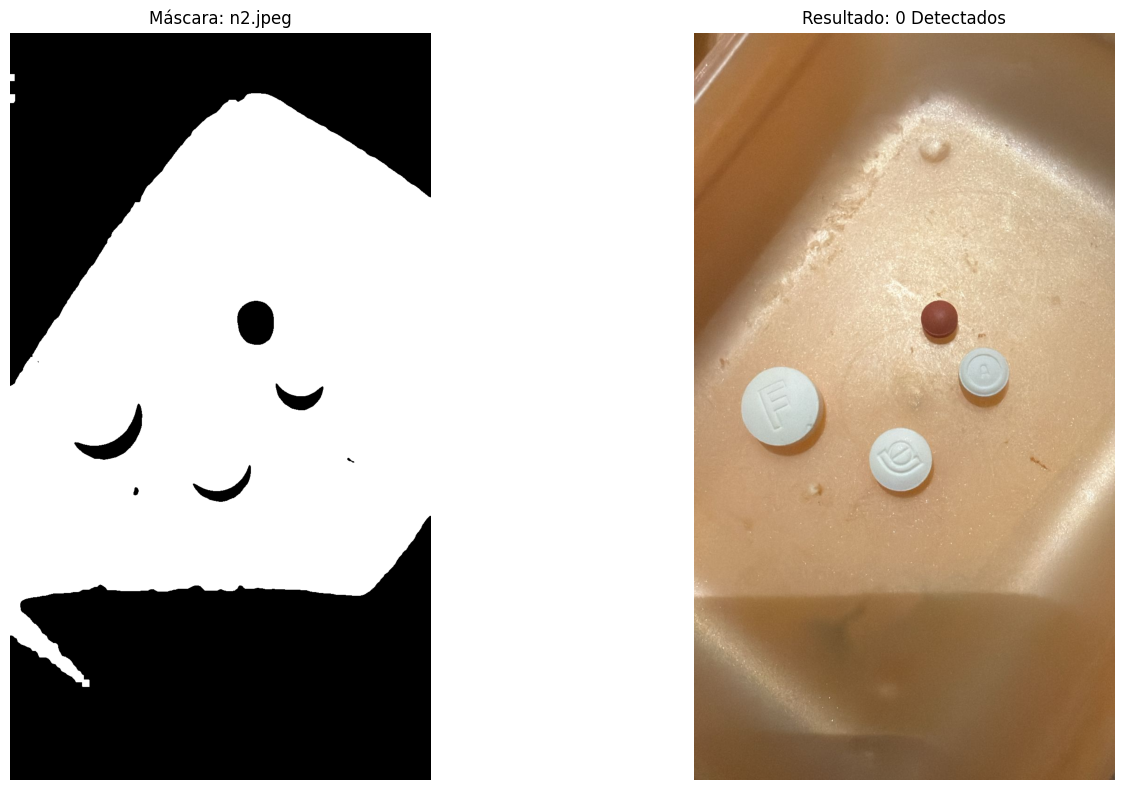

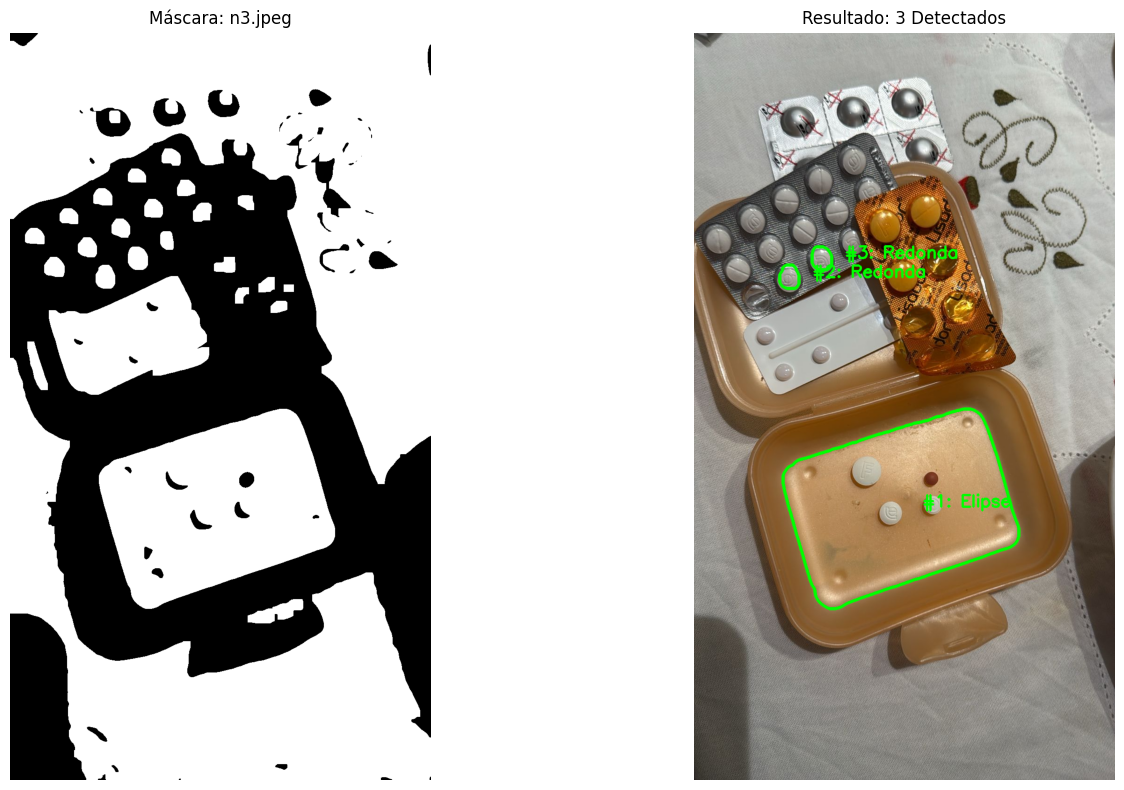

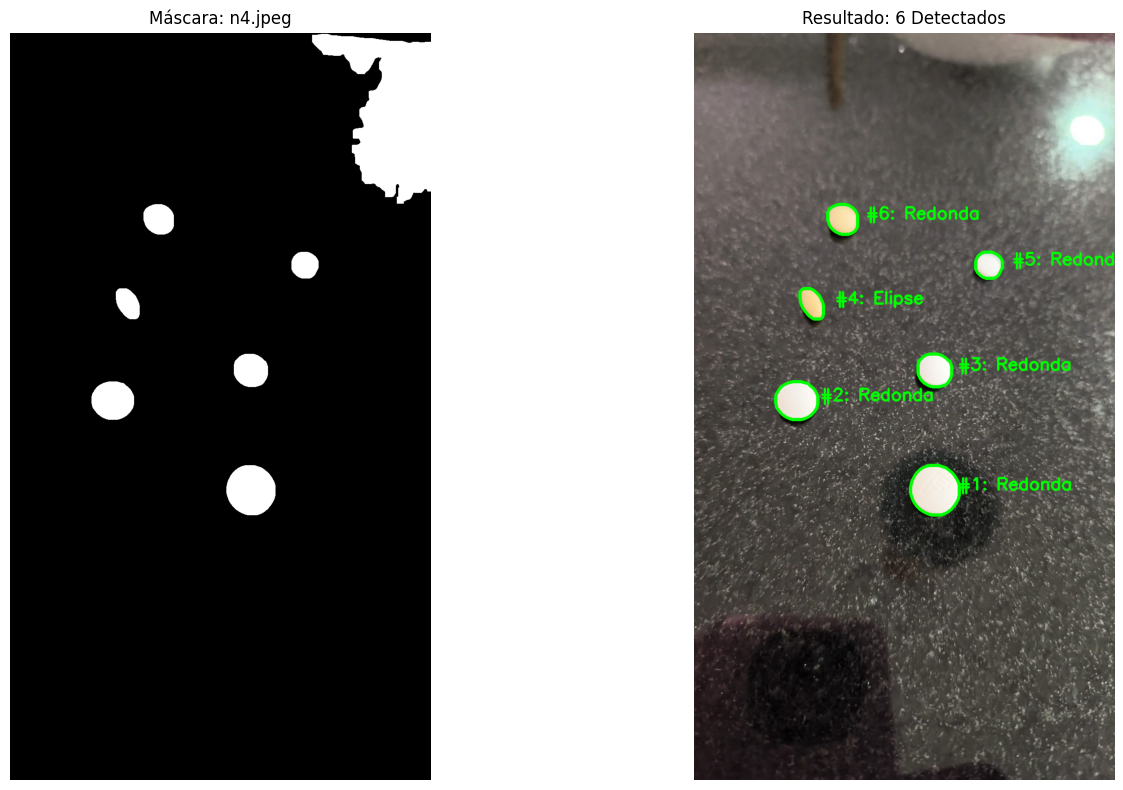

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def exibir_deteccao_comprimidos(caminho_imagem, area_min=1500, circularidade_min=0.6):
    img = cv2.imread(caminho_imagem)
    if img is None:
        print(f"Erro ao carregar: {caminho_imagem}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Pré-processamento
    blur = cv2.GaussianBlur(gray, (21, 21), 0)
    _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morfologia
    kernel = np.ones((15, 15), np.uint8)
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # Contornos
    contours, _ = cv2.findContours(opening, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    result = img_rgb.copy()
    count = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > area_min:
            perimeter = cv2.arcLength(cnt, True)
            circularity = 4 * np.pi * area / (perimeter * perimeter) if perimeter > 0 else 0

            if circularity > circularidade_min:
                count += 1
                
                tipo = "Redonda" if circularity > 0.85 else "Elipse"

                cv2.drawContours(result, [cnt], -1, (0, 255, 0), 5)
                
                M = cv2.moments(cnt)
                cX = int(M["m10"] / M["m00"]) if M["m00"] != 0 else 0
                cY = int(M["m01"] / M["m00"]) if M["m00"] != 0 else 0

                label = f"#{count}: {tipo}"
                cv2.putText(result, label, (cX + 50, cY), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

    plt.figure(figsize=(16, 8))

    plt.subplot(1, 2, 1)
    plt.title(f"Máscara: {os.path.basename(caminho_imagem)}")
    plt.imshow(opening, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Resultado: {count} Detectados")
    plt.imshow(result)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

pasta = "images" 
extensoes = ('.jpg', '.jpeg', '.png')

if os.path.exists(pasta):
    arquivos = [f for f in os.listdir(pasta) if f.lower().endswith(extensoes)]
    for arquivo in arquivos:
        exibir_deteccao_comprimidos(os.path.join(pasta, arquivo))
else:
    print(f"Pasta {pasta} nao encontrada.")